In [1]:
#carga de librerias necesarias para el proyecto 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.stats.proportion import proportions_ztest
from scipy import stats

# Proyecto 10

#### tineda online (Analisis A/b)
empezamos a cargar DF/BD y corroborar que le tipo de infomraicon sea adecauda para cada accion a realziar.


In [2]:
hypotheses = pd.read_csv(r'C:\Users\alber\OneDrive\Desktop\Tripleten\Test\Tripleten\Proyecto 11\hypotheses_us.csv', sep=';')
orders = pd.read_csv(r'C:\Users\alber\OneDrive\Desktop\Tripleten\Test\Tripleten\Proyecto 11\orders_us.csv')
visits = pd.read_csv(r'C:\Users\alber\OneDrive\Desktop\Tripleten\Test\Tripleten\Proyecto 11\visits_us.csv')



In [3]:
hypotheses.columns = hypotheses.columns.str.lower()
print(hypotheses.info())
print(hypotheses.head())

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   hypothesis  9 non-null      str  
 1   reach       9 non-null      int64
 2   impact      9 non-null      int64
 3   confidence  9 non-null      int64
 4   effort      9 non-null      int64
dtypes: int64(4), str(1)
memory usage: 492.0 bytes
None
                                          hypothesis  reach  impact  \
0  Add two new channels for attracting traffic. T...      3      10   
1  Launch your own delivery service. This will sh...      2       5   
2  Add product recommendation blocks to the store...      8       3   
3  Change the category structure. This will incre...      8       3   
4  Change the background color on the main page. ...      3       1   

   confidence  effort  
0           8       6  
1           4      10  
2           7       3  
3           3       8  
4           1       1  


In [4]:
orders['date'] = pd.to_datetime(orders['date'], format= '%Y-%m-%d')
orders.columns = orders.columns.str.lower()
orders.rename(columns={
    'transactionid': 'transaction_id',
    'visitorid': 'visitor_id'
}, inplace=True)
print(orders.info())
print(orders.head())

<class 'pandas.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1197 non-null   int64         
 1   visitor_id      1197 non-null   int64         
 2   date            1197 non-null   datetime64[us]
 3   revenue         1197 non-null   float64       
 4   group           1197 non-null   str           
dtypes: datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 46.9 KB
None
   transaction_id  visitor_id       date  revenue group
0      3667963787  3312258926 2019-08-15     30.4     B
1      2804400009  3642806036 2019-08-15     15.2     B
2      2961555356  4069496402 2019-08-15     10.2     A
3      3797467345  1196621759 2019-08-15    155.1     B
4      2282983706  2322279887 2019-08-15     40.5     B


In [5]:
visits['date']= pd.to_datetime(visits['date'], format='%Y-%m-%d')
print(visits.info())
print(visits.head())

<class 'pandas.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    62 non-null     datetime64[us]
 1   group   62 non-null     str           
 2   visits  62 non-null     int64         
dtypes: datetime64[us](1), int64(1), str(1)
memory usage: 1.6 KB
None
        date group  visits
0 2019-08-01     A     719
1 2019-08-02     A     619
2 2019-08-03     A     507
3 2019-08-04     A     717
4 2019-08-05     A     756


se cargaron y limpiaron los datos, 
- df Hypotheses tenia un separador distinto a , y se tuvo que ajustar en al improtancion a ; 
- df Orders se actualizo el campo date a formato datetime para poder hacer las operaciones necesarias.
- df Visits se actualizo el campo date a formato datetime para poder hacer las operaciones necesarias.

# Priorizar hipótesis
### Aplicar el framework ICE/RICE para priorizar hipótesis. Ordenarlas en orden descendente de prioridad.


In [6]:
hypotheses['ice'] = (hypotheses['impact']*hypotheses['confidence'])/ hypotheses['effort']
hypotheses['rice'] = (
    hypotheses['reach']*hypotheses['impact']*hypotheses['confidence']
    )/ hypotheses['effort']


In [7]:
hypotheses_ice = (
    hypotheses[['hypothesis','ice']]
    .sort_values('ice', ascending=False)
    .reset_index(drop=True)
    )
hypotheses_ice['rank_ice'] = hypotheses_ice['ice'].rank(ascending=False, method= 'first')
print(hypotheses_ice)

                                          hypothesis        ice  rank_ice
0  Launch a promotion that gives users discounts ...  16.200000       1.0
1  Add two new channels for attracting traffic. T...  13.333333       2.0
2  Add a subscription form to all the main pages....  11.200000       3.0
3  Show banners with current offers and sales on ...   8.000000       4.0
4  Add product recommendation blocks to the store...   7.000000       5.0
5  Launch your own delivery service. This will sh...   2.000000       6.0
6  Add a customer review page. This will increase...   1.333333       7.0
7  Change the category structure. This will incre...   1.125000       8.0
8  Change the background color on the main page. ...   1.000000       9.0


In [8]:
hypotheses_rice = (
    hypotheses[['hypothesis','rice']]
    .sort_values('rice', ascending=False)
    .reset_index(drop=True)
    )
hypotheses_rice['rank_rice'] = hypotheses_rice['rice'].rank(ascending=False, method= 'first')
print(hypotheses_rice)

                                          hypothesis   rice  rank_rice
0  Add a subscription form to all the main pages....  112.0        1.0
1  Add product recommendation blocks to the store...   56.0        2.0
2  Add two new channels for attracting traffic. T...   40.0        3.0
3  Show banners with current offers and sales on ...   40.0        4.0
4  Launch a promotion that gives users discounts ...   16.2        5.0
5  Change the category structure. This will incre...    9.0        6.0
6  Launch your own delivery service. This will sh...    4.0        7.0
7  Add a customer review page. This will increase...    4.0        8.0
8  Change the background color on the main page. ...    3.0        9.0


In [9]:
hypotheses_vs = hypotheses_ice[['hypothesis', 'rank_ice']].merge(
    hypotheses_rice[['hypothesis', 'rank_rice']],
    on= 'hypothesis',
    how= 'inner'
)
hypotheses_vs['movement'] = (hypotheses_vs['rank_ice']-hypotheses_vs['rank_rice'])

def arrow(m):
    if m > 0:
        return "⏫"
    elif m < 0:
        return "⏬"
    else:
        return "✅"
    
hypotheses_vs['trend'] = hypotheses_vs['movement'].apply(arrow)

print(hypotheses_vs)


                                          hypothesis  rank_ice  rank_rice  \
0  Launch a promotion that gives users discounts ...       1.0        5.0   
1  Add two new channels for attracting traffic. T...       2.0        3.0   
2  Add a subscription form to all the main pages....       3.0        1.0   
3  Show banners with current offers and sales on ...       4.0        4.0   
4  Add product recommendation blocks to the store...       5.0        2.0   
5  Launch your own delivery service. This will sh...       6.0        7.0   
6  Add a customer review page. This will increase...       7.0        8.0   
7  Change the category structure. This will incre...       8.0        6.0   
8  Change the background color on the main page. ...       9.0        9.0   

   movement trend  
0      -4.0     ⏬  
1      -1.0     ⏬  
2       2.0     ⏫  
3       0.0     ✅  
4       3.0     ⏫  
5      -1.0     ⏬  
6      -1.0     ⏬  
7       2.0     ⏫  
8       0.0     ✅  


se aplicaron los metodos de priorizacion a ICE y RICE al df Hypotheses para determinar cuales hipotesis vna a tener un mayor impacto.
analizando los datos a fondo podemos observar que, la propmocion de cumpleaños no cumple con los requerimeintos de alcance, si bien en la metodologia ice salio en los primeros lugares en rice se desploma por el poco alcance uqe se tiene, a diferentua de la hipoteis donde se plantea agregar un foirmato de suscpcion donde el alcance es mayor por lo que en ICE esta en el rank 3 y en RICE en 1.

cuando incluimos el alcance a nuestras hipotesis, aumentan de valor todas aquellas que tengan o atraigan trafico, ya que esta metrica pesa mucho. 

top 3 hipotesis:
-  Add a subscription form to all the main pages. This will help you compile a mailing list
-  Add product recommendation blocks to the store's site. This will increase conversion and average purchase size
-  Show banners with current offers and sales on the main page. This will boost conversion

# Testeo A/B

1.- Representa gráficamente el ingreso acumulado por grupo. Haz conclusiones y conjeturas.

Text(0.5, 1.0, 'Ingreso acumulado por grupo')

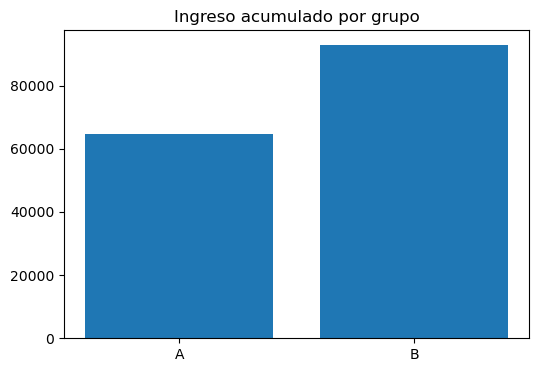

In [10]:
revenue_a = orders[orders['group']== 'A'].copy()
revenue_b = orders[orders['group']== 'B'].copy()
revenue_a_total = revenue_a['revenue'].sum()
revenue_b_total = revenue_b['revenue'].sum()
groups =['A','B']
bar_revenue = [revenue_a_total, revenue_b_total]
plt.figure(figsize=[6,4])
plt.bar(
    groups,
    bar_revenue
)
plt.title('Ingreso acumulado por grupo')

revisando el ingreso acumulado a simple vista podemos observar que el grupo b es quien mas a gastado dentro de nuestras muestras, esta informaiconn es insuficiente para tomar una decision. 

Text(0.5, 0, 'Fecha')

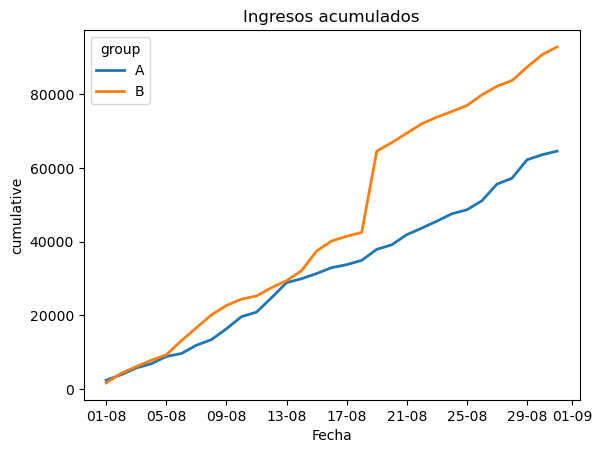

In [11]:
revenue_a_acc = revenue_a.groupby(['group', 'date'])['revenue'].sum().reset_index()
revenue_a_acc['cumulative'] = revenue_a_acc['revenue'].cumsum()
revenue_b_acc = revenue_b.groupby(['group', 'date'])['revenue'].sum().reset_index()
revenue_b_acc['cumulative'] = revenue_b_acc['revenue'].cumsum()
revenue_acc_plot = pd.concat([revenue_a_acc, revenue_b_acc])
sns.lineplot(
    data= revenue_acc_plot,
    x= 'date',
    y= 'cumulative',
    hue= 'group',
    linewidth=2
)
plt.title('Ingresos acumulados')
date_form = mdates.DateFormatter('%d-%m')
plt.gca().xaxis.set_major_formatter(date_form)
plt.xlabel('Fecha')

una vez desglosada la informacion podemos apreciar que ambos grupos tienen un comportamiento similar al inicio, sin emabrgo, el grupo b tuvo un repunto muy abrupto lo cual nos peude indicar que tenememos outliners ya que despues de ese punto se ve que la grafica se mantiene estable.

Text(0.5, 1.0, 'Ingresos por grupos')

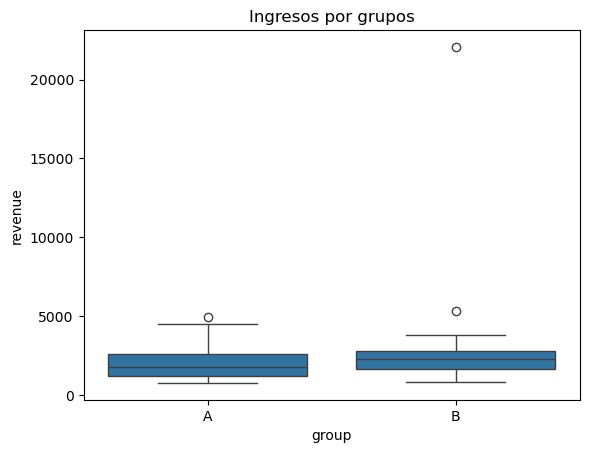

In [12]:
sns.boxplot(
    x='group',
    y='revenue',

    data=revenue_acc_plot
)
plt.title('Ingresos por grupos')


se analizaorn los datos por medio de boxplot para determinar si existian outliners y podemos observar que el grupo b tiene 2 pedidos que inflan las metricas, por lo cual sin esto ambos serian muy similares 

2.- Representa gráficamente el tamaño de pedido promedio acumulado por grupo. Haz conclusiones y conjeturas.

Text(0.5, 1.0, 'Ordenes totales por grupo')

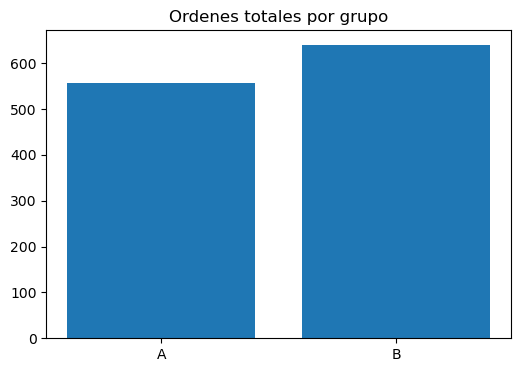

In [13]:
orders_a = orders[orders['group']== 'A'].copy()
orders_b = orders[orders['group']== 'B'].copy()
orders_a_total = orders_a['transaction_id'].count()
orders_b_total = orders_b['transaction_id'].count()
groups =['A','B']
bar_orders = [orders_a_total, orders_b_total]
plt.figure(figsize=[6,4])
plt.bar(
    groups,
    bar_orders
)
plt.title('Ordenes totales por grupo')

Analizando los perdidos podemos observar que en genral el grupo b es quien ams realiza pedidos a comparacion del grupo a

Text(0.5, 0, 'Fecha')

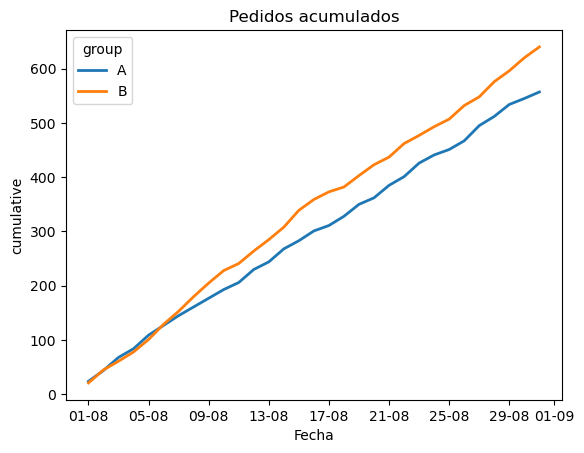

In [14]:
orders_a_acc = orders_a.groupby(['group', 'date'])['transaction_id'].count().reset_index()
orders_a_acc['cumulative'] = orders_a_acc['transaction_id'].cumsum()
orders_b_acc = orders_b.groupby(['group', 'date'])['transaction_id'].count().reset_index()
orders_b_acc['cumulative'] = orders_b_acc['transaction_id'].cumsum()
orders_acc_plot = pd.concat([orders_a_acc, orders_b_acc])
sns.lineplot(
    data= orders_acc_plot,
    x= 'date',
    y= 'cumulative',
    hue= 'group',
    linewidth=2
)
plt.title('Pedidos acumulados')
date_form = mdates.DateFormatter('%d-%m')
plt.gca().xaxis.set_major_formatter(date_form)
plt.xlabel('Fecha')

de igual manera observamos que tenemos una tendencia a la alza estable en ambos grupos sin cambios tan abruptos 

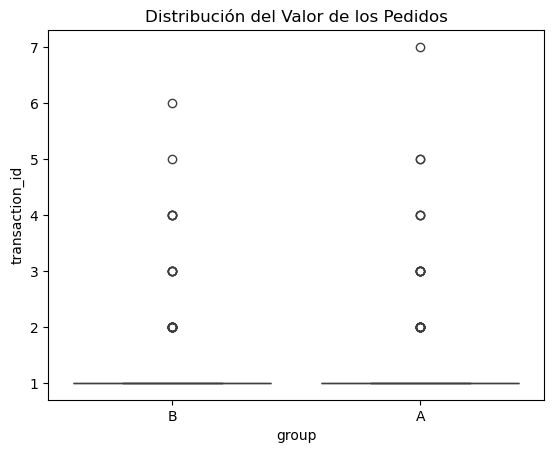

In [15]:
orders_combined = pd.concat([orders_a, orders_b])
orders_per_user = orders_combined.groupby(['visitor_id', 'group'])['transaction_id'].count().reset_index()

sns.boxplot(
    x='group',
    y='transaction_id',
    data=orders_per_user
)
plt.title('Distribución del Valor de los Pedidos')

plt.show()

tratando de anlaizar el comportamiento de los outliners para pedidos si nos encontramos que ambos tienen demasiados outliners, aqui podemos observar que el grupo a es quient tiene mas outliners en contraste con el grupo b.

3.- Representa gráficamente la diferencia relativa en el tamaño de pedido promedio acumulado para el grupo B en comparación con el grupo A. Haz conclusiones y conjeturas.

In [16]:
aov_a = revenue_a['revenue'].sum() / orders_a['transaction_id'].nunique()
aov_b = revenue_b['revenue'].sum() / orders_b['transaction_id'].nunique()
diff_relative = ((aov_b - aov_a) / aov_a)*100
print(f"La diferencia relativia de ticket promedio entre ambos grupos es {diff_relative:.2f}%")

La diferencia relativia de ticket promedio entre ambos grupos es 25.17%


comparando el valor de ticket promedio podmeos observar que entre ambos grupos tenemos una diferencia de alrededor del 25%, lo representa una diferencia significativa.

4.- Calcula la tasa de conversión de cada grupo como la relación entre los pedidos y el número de visitas de cada día. Representa gráficamente las tasas de conversión diarias de los dos grupos y describe la diferencia. Saca conclusiones y haz conjeturas.

count    62.000000
mean      3.290968
std       1.076536
min       1.220000
25%       2.450000
50%       3.255000
75%       4.075000
max       6.230000
Name: cr %, dtype: float64


Text(0.5, 1.0, 'Tasa de conversion')

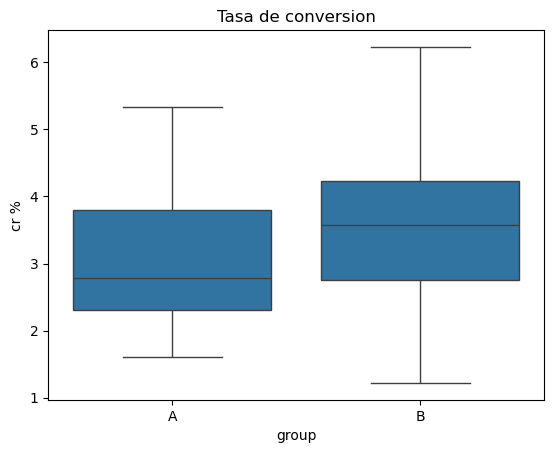

In [17]:

orders_daily = orders.groupby(['date', 'group'])['transaction_id'].nunique().reset_index()
cr = orders_daily.merge(visits, on=['date', 'group'], how= 'right')
cr['orders'] = cr['transaction_id'].fillna(0)
cr['cr'] = cr['orders'] / cr['visits']
cr['cr pct'] = cr['cr'] * 100
cr['cr %'] = cr['cr pct'].apply(lambda x: int(x *100)/100)


cr_pivot = cr.pivot(index='date', columns='group', values='cr')
cr_pivot['diff_rel'] = (cr_pivot['B'] - cr_pivot['A']) / cr_pivot['A']
print(cr['cr %'].describe())

sns.boxplot(
    x= 'group',
    y= 'cr %',
    data= cr    
)
plt.title('Tasa de conversion')


<Axes: xlabel='date', ylabel='cr_cum'>

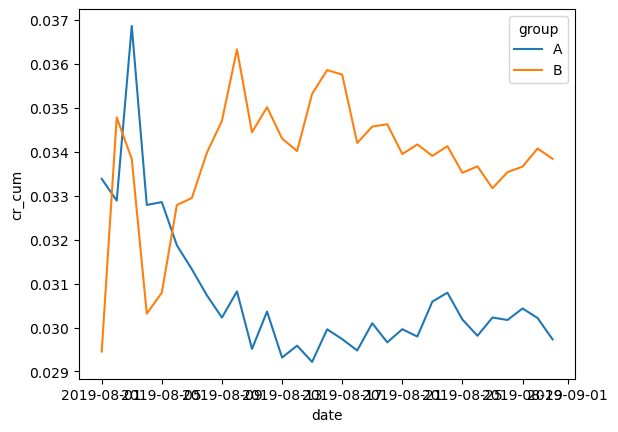

In [18]:
cr = cr.sort_values('date')
cr['orders_cum'] = cr.groupby('group')['transaction_id'].cumsum()
cr['visits_cum'] = cr.groupby('group')['visits'].cumsum()
cr['cr_cum'] = cr['orders_cum'] / cr['visits_cum']

sns.lineplot(
    data=cr,
    x= 'date',
    y= 'cr_cum',
    hue= 'group'
)

revisando la tasa de conversion podemos observar que el diagrama del grupo b es mucho mas amplio, lo cual quiere decir que el grupo b es el que tiene mejores tasas de conversion. 

5.- Traza un gráfico de dispersión del número de pedidos por usuario. Haz conclusiones y conjeturas.

      visitor_id group  orders
0        5114589     B       1
1        6958315     B       1
2        8300375     A       1
3        8300375     B       1
4       11685486     A       1
...          ...   ...     ...
1084  4266935830     B       1
1085  4278982564     A       1
1086  4279090005     B       1
1087  4281247801     B       1
1088  4283872382     B       1

[1089 rows x 3 columns]


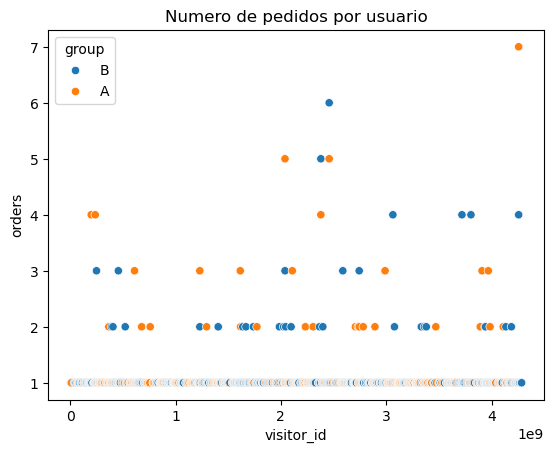

In [19]:
orders_concat = pd.concat([orders_a, orders_b])
orders_per_user = orders_concat.groupby(['visitor_id', 'group']).size().reset_index(name='orders')

sns.scatterplot(data=orders_per_user, x= 'visitor_id', y= 'orders', hue= 'group')
plt.title('Numero de pedidos por usuario')

print(orders_per_user)

se realizo el analiside pedidos, sin embargo, un scatter es ineficiente apra este dataset ya que la amyoria de los usuarios hacen un solo epdido y son pocos los que realizan pedidos con msa frecuencia, podemos observar que un usuario del grupo b es quein ha realizado 7 pedidos. 

para este caso utilizaria mejor un box plot apra poder analizar los outliners mas eficientemente.

6.- Calcula los percentiles 95 y 99 del número de pedidos por usuario. Define el punto en el cual un punto de datos se convierte en una anomalía

In [20]:
np.percentile(orders_per_user['orders'], 90)
np.percentile(orders_per_user['orders'], 95)
np.percentile(orders_per_user['orders'], 99)

print(f"El 90% de los clientes solo han comprado {np.percentile(orders_per_user['orders'], 90)} o menos productos.")
print(f"El 95% de los clientes compran {np.percentile(orders_per_user['orders'], 95)} o menos productos.")
print(f"El 99% de los cleintes realizan {np.percentile(orders_per_user['orders'], 99)} compras o menos.")


El 90% de los clientes solo han comprado 1.0 o menos productos.
El 95% de los clientes compran 2.0 o menos productos.
El 99% de los cleintes realizan 4.0 compras o menos.


revisando al informaicon podemos identificar que cualqeuir usuario que realice mas de 4 pedidos se debe de conciderar un outliner, a los cuales les podriamos llamar cleintes VIP.

7.- Traza un gráfico de dispersión de los precios de los pedidos. Haz conclusiones y conjeturas.

Text(0.5, 1.0, 'Distribucion de precios por usuario')

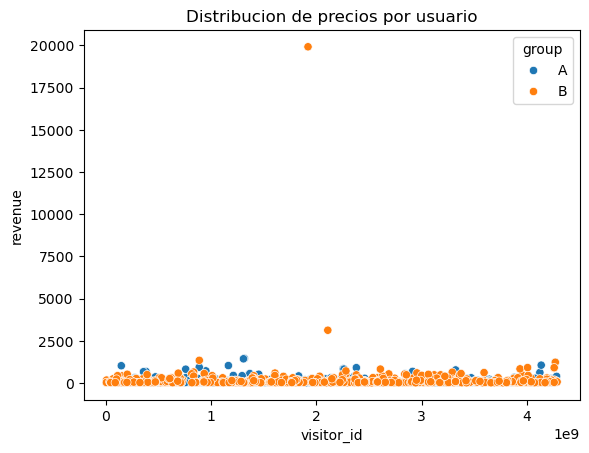

In [21]:
sns.scatterplot(data=orders_concat, x= 'visitor_id', y='revenue', hue='group')
plt.title('Distribucion de precios por usuario')


Text(0.5, 1.0, 'Distribucion de precios por fecha')

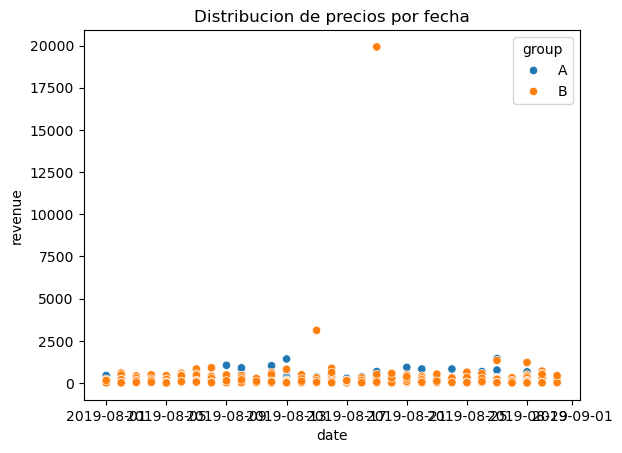

In [22]:
sns.scatterplot(data= orders_concat, x= 'date', y= 'revenue', hue= 'group')
plt.title('Distribucion de precios por fecha')

revisamos la distribucinion de reveneu por usuario y pdemos observar que los usuraios del grupo b tienen outliners, lo cual significa uqe los usuarios del grupo b gastan mas. 

si analizamos la distribucion por fecha podemos observar una distribucion similar, lo cual confimra que que el grupo b es el mas activo.

8.- Calcula los percentiles 95 y 99 de los precios de los pedidos. Define el punto en el cual un punto de datos se convierte en una anomalía.

In [23]:
print(f"El 90% del valor de los pedidos es de ${np.percentile(orders_concat['revenue'], 90):.2f} o menos.")
print(f"El 95% del valor de los pedidos es de ${np.percentile(orders_concat['revenue'], 95):.2f} o menos.")
print(f"El 99% del valor de los pedidos es de ${np.percentile(orders_concat['revenue'], 99):.2f} o menos.")


El 90% del valor de los pedidos es de $282.48 o menos.
El 95% del valor de los pedidos es de $435.54 o menos.
El 99% del valor de los pedidos es de $900.90 o menos.


9.- Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos en bruto. Haz conclusiones y conjeturas.

H0= no existe diferencia entre la tasa de conversion entre el grupo a y grupo b.
H1= existe una diferencia significativa entre la tasa de conversio de los grupos a y b.

In [24]:
visits_daily = visits.groupby(['date', 'group'])['visits'].sum().reset_index()

print(visits_daily)

         date group  visits
0  2019-08-01     A     719
1  2019-08-01     B     713
2  2019-08-02     A     619
3  2019-08-02     B     581
4  2019-08-03     A     507
..        ...   ...     ...
57 2019-08-29     B     531
58 2019-08-30     A     490
59 2019-08-30     B     490
60 2019-08-31     A     699
61 2019-08-31     B     718

[62 rows x 3 columns]


In [25]:
z_orders_a = orders_concat[orders_concat['group']=='A']['transaction_id'].count()
z_orders_b = orders_concat[orders_concat['group']=='B']['transaction_id'].count()
z_visits_a = visits_daily[visits_daily['group'] == 'A']['visits'].sum()
z_visits_b = visits_daily[visits_daily['group'] == 'B']['visits'].sum()

z_stats, p_value1 = proportions_ztest([z_orders_a, z_orders_b], [z_visits_a, z_visits_b])
conversion_a = z_orders_a / z_visits_a
conversion_b = z_orders_b / z_visits_b
relative_diference = ((conversion_b / conversion_a)-1)*100
alpha = 0.05

if p_value1 < alpha:
    print("Decision: 1. Parar la prueba. El grupo B es el líder indiscutible (H1).")
else:
    print("Decision: 2. No hay diferencia significativa todavía (H0).")
print(f"P-value: {p_value1:.4f}")
print(f"Diferencia relativa {relative_diference:.2f}%")

Decision: 1. Parar la prueba. El grupo B es el líder indiscutible (H1).
P-value: 0.0232
Diferencia relativa 13.81%


In [26]:


orders_by_users = (
    orders
    .groupby(['visitor_id', 'group'])['transaction_id']
    .nunique()
    .reset_index(name= 'orders')
)

orders_cutoff = orders_by_users['orders'].quantile(.95)

users_many_orders = orders_by_users[
    orders_by_users['orders'] > orders_cutoff
]['visitor_id']

revenue_cutoff = orders['revenue'].quantile(.95)

user_expensive = orders[
    orders['revenue'] > revenue_cutoff
]['visitor_id']

abnormal_users = pd.concat(
    [users_many_orders, user_expensive]
).drop_duplicates()




In [27]:


visits_by_group = visits.groupby('group')['visits'].sum()

orders_by_users_a = orders_by_users[orders_by_users['group'] == 'A']['orders']
orders_by_users_b = orders_by_users[orders_by_users['group'] == 'B']['orders']

zero_visits_a = visits_by_group['A'] - orders_by_users_a.count()
zero_visits_b = visits_by_group['B'] - orders_by_users_b.count()

sample_zero_a = pd.concat([orders_by_users_a, pd.Series([0] * zero_visits_a)])
sample_zero_b = pd.concat([orders_by_users_b, pd.Series([0] * zero_visits_b)])

mean_zero_sample_a = sample_zero_a.mean()
mean_zero_sample_b = sample_zero_b.mean()
relative_diff = ((mean_zero_sample_b / mean_zero_sample_a) - 1) * 100

u_stat, p_value2 = stats.mannwhitneyu(
    sample_zero_a,
    sample_zero_b
)

alpha= .05
if p_value2 < alpha:
    print("Conclusión: Existe diferencia significativa en la conversión por usuario (H1).")
else:
    print("Conclusión: No se detecta diferencia significativa en la conversión por usuario (H0).")

print(f"P-value: {p_value2:.4f}")
print(f'Diferencia relativa: {relative_diff:.2f}%')



Conclusión: Existe diferencia significativa en la conversión por usuario (H1).
P-value: 0.0168
Diferencia relativa: 13.81%


In [28]:

orders_filtered = orders[~orders['visitor_id'].isin(abnormal_users)]
visits_filtered = visits.copy()

orders_by_users_filtered = (
   orders_filtered
    .groupby(['visitor_id', 'group'])['transaction_id']
    .nunique()
    .reset_index(name='orders')   
)

orders_filtered_a = orders_by_users_filtered[orders_by_users_filtered['group'] == 'A']['orders']
orders_filtered_b = orders_by_users_filtered[orders_by_users_filtered['group'] == 'B']['orders']

visits_by_group = visits.groupby('group')['visits'].sum()

zero_visits_a = visits_by_group['A'] - orders_filtered_a.count()
zero_visits_b = visits_by_group['B'] - orders_filtered_b.count()

filtered_sample_a = pd.concat([orders_filtered_a, pd.Series([0] * zero_visits_a)])
filtered_sample_b = pd.concat([orders_filtered_b, pd.Series([0] * zero_visits_b)])

u_stat, p_value3 = stats.mannwhitneyu(
    filtered_sample_a, 
    filtered_sample_b
)

filtered_mean_a = filtered_sample_a.mean()
filtered_mean_b = filtered_sample_b.mean()
relative_difference = (filtered_mean_b / filtered_mean_a)

if p_value3 < alpha:
    print(
        'Parar la prueba. Existe una diferenica significativa entre al covnersion por usuario'
    )
else: 
    print(
        'No se detectan diferencias significativas'
    )

print(f'P-value: {p_value3:.4f}')
print(f'Diferencia relativa: {relative_difference:.2f}%')

Parar la prueba. Existe una diferenica significativa entre al covnersion por usuario
P-value: 0.0131
Diferencia relativa: 1.17%


para este punto se realizaron 3 pruebas;
- Z-test, para conversion agregada.
- Mann-Whitney, de todos los usuarios incluyendo sin pedidos.
- Mann-Whitney, excluyendo usuarios atipicos.

revisando los resultados podemos observar una diferencia significativa entre los grupos a y b. 

para este punto se decide parar la prueba ya que existe un mejor desempeño del grupo b.

10.- Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos en bruto. Haz conclusiones y conjeturas.

H0= el ticket promedio (AOV) es igual en ambos grupos.

H1= el ticket promedio (AOV) del grupo a es diferente al grupo b.

In [29]:
revenue_a_test = revenue_a['revenue']
revenue_b_test = revenue_b['revenue'] 

revenue_a_mean = revenue_a_test.mean()
revenue_b_mean = revenue_b_test.mean()

revenue_mean = ((revenue_b_mean / revenue_a_mean)-1)*100

m_stats, pvalue = stats.mannwhitneyu(revenue_a_test, revenue_b_test)

if pvalue < alpha:
    print("Decision: 1. Parar la prueba. Hay diferencia significativa en el ticket promedio (H1).")
else:
    print("Decision: 2. Continuar la prueba o aceptar H0. No hay diferencia significativa en el ticket promedio.")
print(f"P-value: {pvalue:.2f}")
print(f"Diferencia relativa {revenue_mean:.2f}%")

Decision: 2. Continuar la prueba o aceptar H0. No hay diferencia significativa en el ticket promedio.
P-value: 0.69
Diferencia relativa 25.17%


11.- Encuentra la significancia estadística de la diferencia en la conversión entre los grupos utilizando los datos filtrados. Haz conclusiones y conjeturas.

H0= la conversion de clientes es igual en ambos grupos.

H1= la conversion entre el grupo a y b es diferente.

In [30]:
orders_filtered = orders[~orders['visitor_id'].isin(abnormal_users)]

orders_filtered_a = orders_filtered[orders_filtered['group']== 'A']['revenue']
orders_filtered_b = orders_filtered[orders_filtered['group']== 'B']['revenue']

In [31]:



visitors_a = visits[visits['group'] == 'A']['visits'].sum()
visitors_b = visits[visits['group'] == 'B']['visits'].sum()

filtered_cr_orders_a = orders_filtered[orders_filtered['group'] == 'A']['transaction_id'].nunique()
filtered_cr_orders_b = orders_filtered[orders_filtered['group'] == 'B']['transaction_id'].nunique()

cr_a = filtered_cr_orders_a / visitors_a
cr_b = filtered_cr_orders_b / visitors_b

cr_difference = ((cr_b / cr_a)-1) * 100

cr_stats, cr_pvalue = proportions_ztest([filtered_cr_orders_a, filtered_cr_orders_b], [visitors_a, visitors_b])

if cr_pvalue < alpha:
    print("Decision: 1. Parar la prueba. Hay diferencia significativa en la conversión (H1).")
else:
    print("Decision: 2. Continuar la prueba o aceptar H0. No hay diferencia significativa en la conversión (H0).")
print(f"P-value: {((cr_pvalue)*100):.2f}%")

print(f"Diferencia relativa {cr_difference:.2f}%")




Decision: 1. Parar la prueba. Hay diferencia significativa en la conversión (H1).
P-value: 0.96%
Diferencia relativa 17.27%


12.- Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido entre los grupos utilizando los datos filtrados. Haz conclusiones y conjeturas.

In [32]:
mean_filtered_a = orders_filtered[orders_filtered['group']== 'A']['revenue'].mean()
mean_filtered_b = orders_filtered[orders_filtered['group']== 'B']['revenue'].mean()

aov_difference = ((mean_filtered_b / mean_filtered_a)-1)*100

aov_stats, aov_pvalue = stats.mannwhitneyu(orders_filtered_a, orders_filtered_b)
alpha = .05

if aov_pvalue < alpha:
    print("Conclusión: Rechazamos H0. Hay diferencia significativa entre A y B.")
else:
    print("Conclusión: No podemos rechazar H0. Los grupos son iguales estadísticamente.")



Conclusión: No podemos rechazar H0. Los grupos son iguales estadísticamente.


13.- Toma una decisión basada en los resultados de la prueba. Las decisiones posibles son:
 1. Parar la prueba, considerar a uno de los grupos como líder. 
 2. Parar la prueba, concluir que no hay diferencia entre los grupos. 
 3. Continuar la prueba.

Analizamos la información completa de este caso. Debemos tomar la opción 1: parar la prueba y considerar al grupo B como líder en conversión, porque la conversión bruta y filtrada son significativas (p < 0.05). El AOV no es significativo, por lo que la diferencia principal se da en conversión, no en ticket promedio. 